In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from dataclasses import dataclass
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [8]:
def simulate_intraday(n_bars=780, true_theta=0.08, true_sigma=0.015, dt=1.0,
                       drift=0.0002, base_price=100.0, seed=42):
    rng = np.random.default_rng(seed)
    log_v = np.zeros(n_bars)
    log_v[0] = np.log(base_price)
    rw_shocks = rng.normal(drift, 0.0008, size=n_bars - 1)
    log_v[1:] = log_v[0] + np.cumsum(rw_shocks)

    D = np.zeros(n_bars)
    D[0] = rng.normal(0, true_sigma / np.sqrt(2 * true_theta))
    ou_std = true_sigma * np.sqrt((1 - np.exp(-2 * true_theta * dt)) / (2 * true_theta))
    for t in range(1, n_bars):
        D[t] = D[t - 1] * np.exp(-true_theta * dt) + rng.normal(0, ou_std)

    log_price = log_v + D
    price = np.exp(log_price)

    t_norm = np.linspace(-1, 1, n_bars)
    u_shape = 1.0 + 0.6 * t_norm ** 2
    base_vol = rng.lognormal(mean=7.0, sigma=0.35, size=n_bars) * u_shape
    flow_boost = 1.0 + 3.0 * np.abs(D) / true_sigma
    volume = np.clip((base_vol * flow_boost).round().astype(int), 50, None)

    idx = pd.date_range("2026-09-25 09:30", periods=n_bars, freq="30s")
    return pd.DataFrame({"price": price, "volume": volume, "true_D": D}, index=idx)


def compute_vwap_deviation(price, volume):
    cum_pv = (price * volume).cumsum()
    cum_v = volume.cumsum()
    vwap = cum_pv / cum_v
    return np.log(price) - np.log(vwap), vwap

In [9]:
@dataclass
class OUFitResult:
    phi: float; const: float; theta: float; mu: float; half_life: float
    sigma_ou: float; sigma_stat: float; resid_std: float
    adf_pvalue: float; r_squared: float


def fit_ar1(D, delta=1.0):
    D = D.dropna()
    y, x = D.iloc[1:].values, D.iloc[:-1].values
    model = sm.OLS(y, sm.add_constant(x)).fit()
    const, phi = model.params
    resid_std = np.std(model.resid, ddof=2)
    if not (0 < phi < 1):
        raise ValueError(f"phi={phi:.4f} outside (0,1): not mean-reverting.")
    theta = -np.log(phi) / delta
    mu = const / (1 - phi)
    half_life = np.log(2) / theta
    sigma_ou = resid_std * np.sqrt(2 * theta / (1 - phi ** 2))
    sigma_stat = sigma_ou / np.sqrt(2 * theta)
    adf_p = adfuller(D, autolag="AIC")[1]
    return OUFitResult(phi, const, theta, mu, half_life, sigma_ou, sigma_stat, resid_std, adf_p, model.rsquared)

In [10]:
class BayesianOUEstimator:
    def __init__(self, delta=1.0, beta0=(0.0, 0.9), V0_diag=(1.0, 1.0), a0=2.0, b0=1e-4):
        self.delta = delta
        self.beta = np.array(beta0, dtype=float)
        self.V = np.diag(V0_diag).astype(float)
        self.Vinv = np.linalg.inv(self.V)
        self.a, self.b, self.n = a0, b0, 0

    def update(self, x, y):
        x, y = np.atleast_1d(x).astype(float), np.atleast_1d(y).astype(float)
        X = np.column_stack([np.ones_like(x), x])
        Vinv_new = self.Vinv + X.T @ X
        V_new = np.linalg.inv(Vinv_new)
        beta_new = V_new @ (self.Vinv @ self.beta + X.T @ y)
        a_new = self.a + len(x) / 2
        b_new = self.b + 0.5 * (y @ y + self.beta @ self.Vinv @ self.beta - beta_new @ Vinv_new @ beta_new)
        self.Vinv, self.V, self.beta, self.a, self.b = Vinv_new, V_new, beta_new, a_new, b_new
        self.n += len(x)

    def posterior_ou_params(self, n_samples=4000, seed=0):
        rng = np.random.default_rng(seed)
        sigma2_draws = 1.0 / rng.gamma(self.a, 1.0 / self.b, size=n_samples)
        beta_draws = np.array([rng.multivariate_normal(self.beta, s2 * self.V) for s2 in sigma2_draws])
        c_draws, phi_draws = beta_draws[:, 0], beta_draws[:, 1]
        valid = (phi_draws > 0) & (phi_draws < 1)
        c_draws, phi_draws, sigma2_draws = c_draws[valid], phi_draws[valid], sigma2_draws[valid]
        theta_draws = -np.log(phi_draws) / self.delta
        mu_draws = c_draws / (1 - phi_draws)
        half_life_draws = np.log(2) / theta_draws
        sigma_ou_draws = np.sqrt(sigma2_draws) * np.sqrt(2 * theta_draws / (1 - phi_draws ** 2))
        summarize = lambda a: dict(mean=np.mean(a), lo95=np.percentile(a, 2.5), hi95=np.percentile(a, 97.5))
        return {"phi": summarize(phi_draws), "theta": summarize(theta_draws), "mu": summarize(mu_draws),
                "half_life": summarize(half_life_draws), "sigma_ou": summarize(sigma_ou_draws), "n_obs": self.n}

In [11]:
def backtest(D, price, entry_k, exit_k, sigma_stat, cost_bps=2.0, notional=10_000.0):
    entry_level, exit_level = entry_k * sigma_stat, exit_k * sigma_stat
    position, entry_price, entry_time = 0, None, None
    trades, equity, running_pnl = [], np.zeros(len(D)), 0.0
    cost = notional * cost_bps / 1e4
    D_vals, P_vals, idx = D.values, price.values, D.index

    for i in range(len(D_vals)):
        d, p = D_vals[i], P_vals[i]
        if position == 0:
            if d <= -entry_level:
                position, entry_price, entry_time = 1, p, idx[i]
            elif d >= entry_level:
                position, entry_price, entry_time = -1, p, idx[i]
        elif position == 1 and d >= -exit_level:
            shares = notional / entry_price
            pnl = shares * (p - entry_price) - cost
            running_pnl += pnl
            trades.append(dict(side="long", entry_time=entry_time, exit_time=idx[i],
                                entry_price=entry_price, exit_price=p, pnl=pnl))
            position, entry_price, entry_time = 0, None, None
        elif position == -1 and d <= exit_level:
            shares = notional / entry_price
            pnl = shares * (entry_price - p) - cost
            running_pnl += pnl
            trades.append(dict(side="short", entry_time=entry_time, exit_time=idx[i],
                                entry_price=entry_price, exit_price=p, pnl=pnl))
            position, entry_price, entry_time = 0, None, None

        open_pnl = 0.0
        if position == 1: open_pnl = (notional / entry_price) * (p - entry_price)
        elif position == -1: open_pnl = (notional / entry_price) * (entry_price - p)
        equity[i] = running_pnl + open_pnl

    return pd.DataFrame(trades), pd.Series(equity, index=idx)


def optimize_bands(D_train, price_train, sigma_stat,
                    entry_grid=np.linspace(0.5, 3.0, 11), exit_grid=np.linspace(0.0, 1.5, 7), cost_bps=2.0):
    best = None
    for ek in entry_grid:
        for xk in exit_grid:
            if xk >= ek: continue
            trades, equity = backtest(D_train, price_train, ek, xk, sigma_stat, cost_bps)
            if len(trades) < 5: continue
            avg_hold = (equity.index[-1] - equity.index[0]).total_seconds() / max(len(trades), 1)
            score = trades["pnl"].sum() / avg_hold
            if best is None or score > best["score"]:
                best = dict(entry_k=ek, exit_k=xk, score=score, n_trades=len(trades))
    return best


# --- run everything ---
df = simulate_intraday()
D, vwap = compute_vwap_deviation(df["price"], df["volume"])
df["D"], df["vwap"] = D, vwap

split = len(df) // 2
train, test = df.iloc[:split], df.iloc[split:]

ols_fit = fit_ar1(train["D"])
bayes = BayesianOUEstimator()
Dt = train["D"].values
for t in range(1, len(Dt)):
    bayes.update(Dt[t - 1], Dt[t])
post = bayes.posterior_ou_params()

best_bands = optimize_bands(train["D"], train["price"], ols_fit.sigma_stat)
trades, equity = backtest(test["D"], test["price"], best_bands["entry_k"], best_bands["exit_k"], ols_fit.sigma_stat)

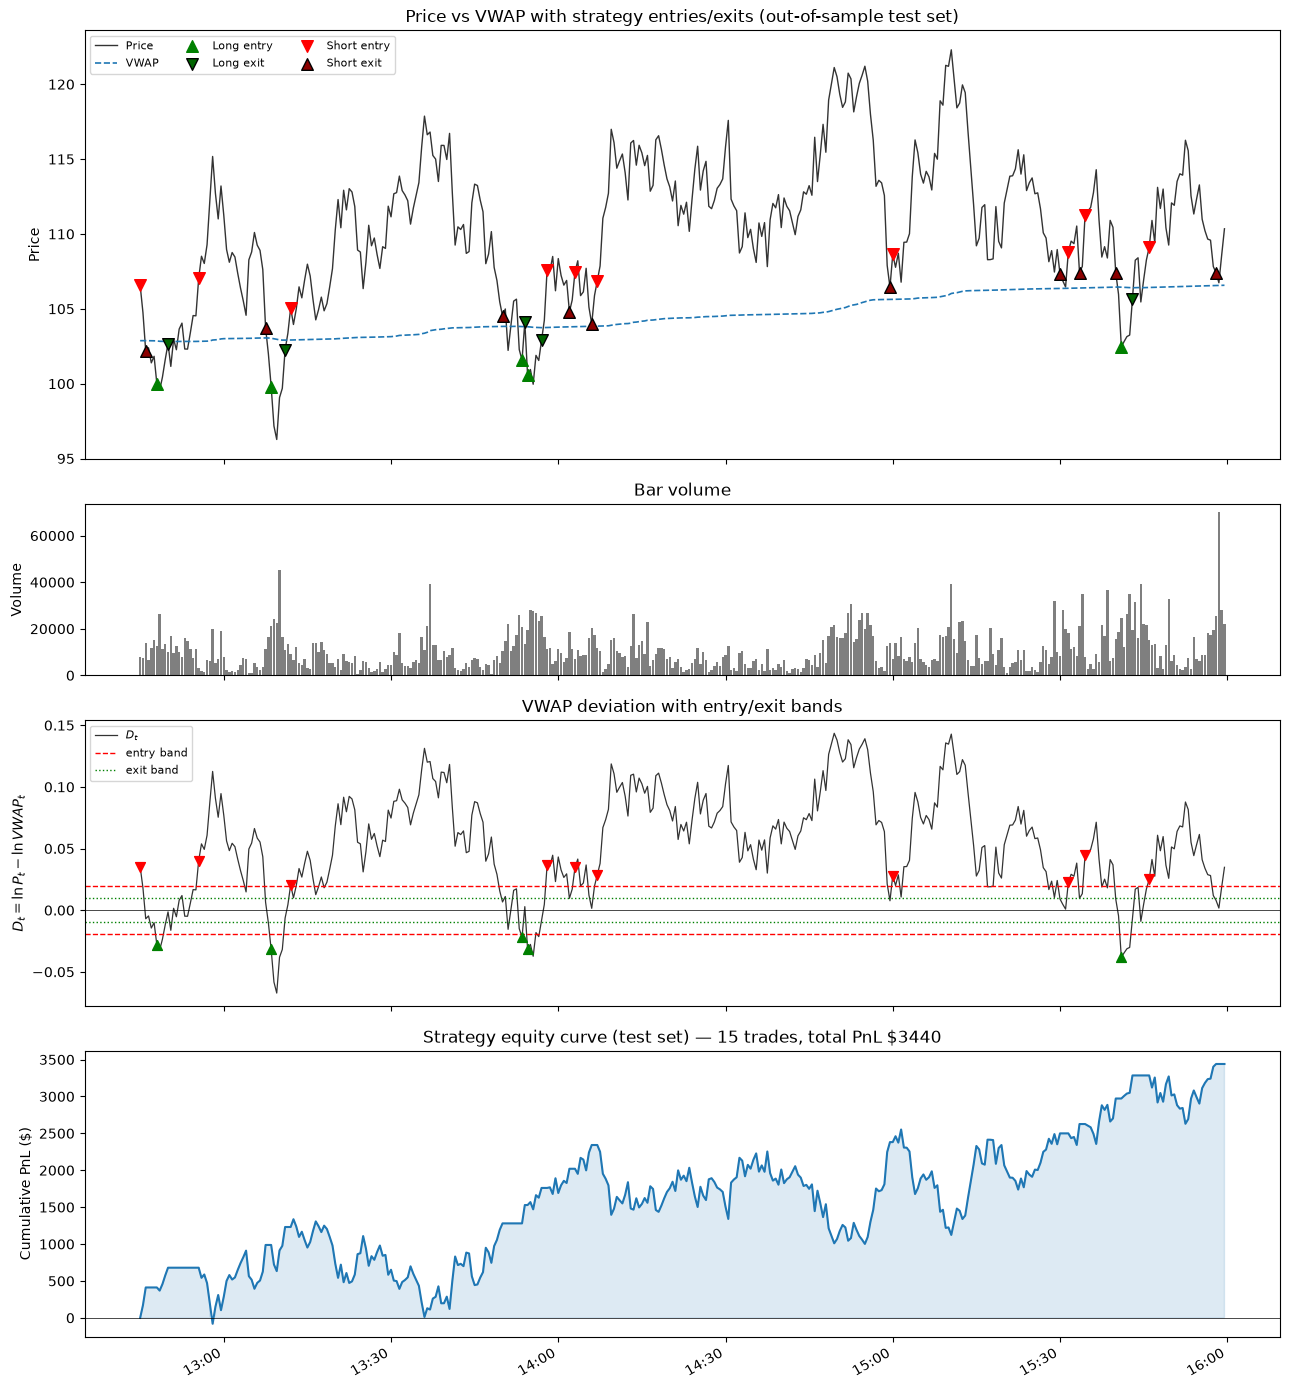

In [12]:
entry_level = best_bands["entry_k"] * ols_fit.sigma_stat
exit_level = best_bands["exit_k"] * ols_fit.sigma_stat

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.2, 2, 2]})

# Panel 1: price + VWAP + entries/exits
ax = axes[0]
ax.plot(test.index, test["price"], color="#333333", lw=1, label="Price")
ax.plot(test.index, test["vwap"], color="#1f77b4", lw=1.2, ls="--", label="VWAP")

longs = trades[trades["side"] == "long"]
shorts = trades[trades["side"] == "short"]

if len(longs):
    ax.scatter(longs["entry_time"], longs["entry_price"], marker="^", color="green",
               s=70, zorder=5, label="Long entry")
    ax.scatter(longs["exit_time"], longs["exit_price"], marker="v", color="darkgreen",
               s=70, zorder=5, edgecolor="k", label="Long exit")
if len(shorts):
    ax.scatter(shorts["entry_time"], shorts["entry_price"], marker="v", color="red",
               s=70, zorder=5, label="Short entry")
    ax.scatter(shorts["exit_time"], shorts["exit_price"], marker="^", color="darkred",
               s=70, zorder=5, edgecolor="k", label="Short exit")

ax.set_title("Price vs VWAP with strategy entries/exits (out-of-sample test set)")
ax.set_ylabel("Price")
ax.legend(loc="upper left", fontsize=8, ncol=3)

# Panel 2: volume bars
ax = axes[1]
ax.bar(test.index, test["volume"], width=0.0003, color="#7f7f7f")
ax.set_ylabel("Volume")
ax.set_title("Bar volume")

# Panel 3: D_t with entry/exit bands
ax = axes[2]
ax.plot(test.index, test["D"], color="#333333", lw=0.9, label="$D_t$")
ax.axhline(entry_level, color="red", ls="--", lw=1, label="entry band")
ax.axhline(-entry_level, color="red", ls="--", lw=1)
ax.axhline(exit_level, color="green", ls=":", lw=1, label="exit band")
ax.axhline(-exit_level, color="green", ls=":", lw=1)
ax.axhline(0, color="black", lw=0.5)

if len(longs):
    ax.scatter(longs["entry_time"], test["D"].reindex(longs["entry_time"]),
               marker="^", color="green", s=50, zorder=5)
if len(shorts):
    ax.scatter(shorts["entry_time"], test["D"].reindex(shorts["entry_time"]),
               marker="v", color="red", s=50, zorder=5)

ax.set_ylabel("$D_t = \\ln P_t - \\ln VWAP_t$")
ax.set_title("VWAP deviation with entry/exit bands")
ax.legend(loc="upper left", fontsize=8)

# Panel 4: equity curve
ax = axes[3]
ax.plot(equity.index, equity.values, color="#1f77b4", lw=1.5)
ax.fill_between(equity.index, equity.values, 0, where=(equity.values >= 0), color="#1f77b4", alpha=0.15)
ax.fill_between(equity.index, equity.values, 0, where=(equity.values < 0), color="#d62728", alpha=0.15)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Cumulative PnL ($)")
ax.set_title(f"Strategy equity curve (test set) — {len(trades)} trades, total PnL ${trades['pnl'].sum():.0f}")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()